In [1]:
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.5
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)

In [2]:
# Convolutional Neural Network

# Importing the libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,Conv1D,MaxPooling1D,BatchNormalization,PReLU
from tensorflow.keras.optimizers import SGD,AdamW,Adagrad,RMSprop,Adam,Nadam,Adadelta
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC  
import matplotlib.pyplot as plt
import numpy as np

In [4]:
tf.__version__

'2.18.0'

In [5]:
# re-size all the images to this
IMAGE_SIZE = [224, 224]

train_path = 'Datasets/train'
valid_path = 'Datasets/val'

In [6]:
from glob import glob

In [7]:
folders = glob('Dataset/*')

In [8]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [9]:
# Make sure you provide the same target size as initialied for the image size
training_set = train_datagen.flow_from_directory('Dataset/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 shuffle=False,
                                                 class_mode = 'categorical')

Found 1396 images belonging to 9 classes.


In [10]:
test_set = test_datagen.flow_from_directory('Dataset/val/val',
                                            target_size = (224, 224),
                                        batch_size = 32,
                                            shuffle=False,
                                            class_mode = 'categorical')
accuracy_list=list()
epoch=100

Found 349 images belonging to 9 classes.


# Adam


C:\Users\musta\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\musta\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.0476 - loss: 8.6905 - val_accuracy: 0.1146 - val_loss: 2.2158
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.0788 - loss: 2.2398 - val_accuracy: 0.1146 - val_loss: 2.1970
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.0426 - loss: 2.1976 - val_accuracy: 0.1146 - val_loss: 2.1968
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.1241 - loss: 2.1957 - val_accuracy: 0.1146 - val_loss: 2.1965
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.1614 - loss: 2.1971 - val_accuracy: 0.1146 - val_loss: 2.1963
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.0678 - loss: 2.1976 - val_accuracy: 0.1146 - val_loss: 2.1956
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.0811 - loss: 2.1932 - val_accuracy: 0.1777 - val_loss: 2.1165
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.2468 - loss: 2.0297 - val_accuracy: 0.3209 - v

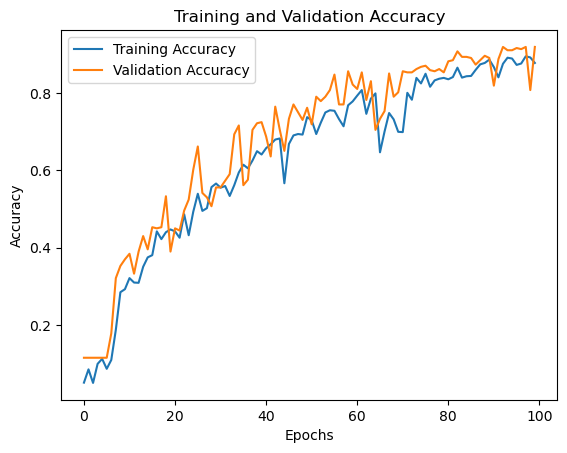

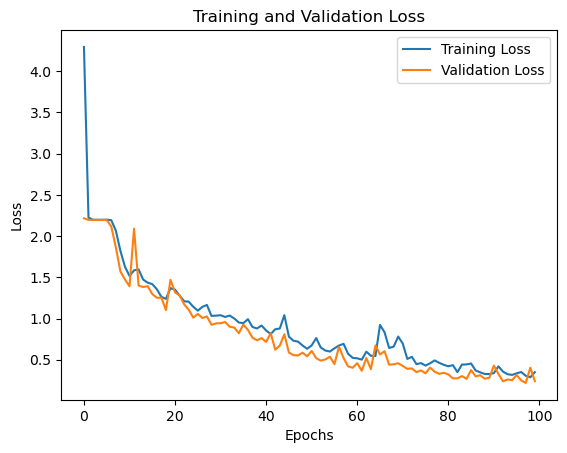

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 435ms/step
[0.9197707736389685]


In [11]:
model = Sequential()
model.add(Conv2D(filters=32,kernel_size=3, strides=2,padding="same",input_shape=[224, 224, 3],)),PReLU(),
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Conv2D(64,kernel_size = (1,1),strides = (1,1),activation='relu'))
model.add(Conv2D(192,kernel_size = (3,3),strides = (1,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Flatten())

model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(9,activation = 'sigmoid'))
#adam sgd rmsprop,adagrad,adamw

#opt =SGD(learning_rate=0.01, momentum=0.9) #stochastic Gradient Descent
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])



# Training the CNN on the Training set and evaluating it on the Test set
r=model.fit(x = training_set, validation_data = test_set, epochs =epoch)





plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
Y_pred = model.predict(test_set)
y_pred = np.argmax(Y_pred, axis=1)
count=0
count=sum(y_pred==test_set.classes)
Acc=count/349
accuracy_list.append(Acc)
print(accuracy_list)

# SGD


Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.0411 - loss: 2.3503 - val_accuracy: 0.1146 - val_loss: 2.1974
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.0920 - loss: 2.2115 - val_accuracy: 0.1146 - val_loss: 2.1954
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.0643 - loss: 2.2214 - val_accuracy: 0.2292 - val_loss: 2.1949
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.0601 - loss: 2.2182 - val_accuracy: 0.1146 - val_loss: 2.1932
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.0715 - loss: 2.1964 - val_accuracy: 0.1146 - val_loss: 2.1938
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.0797 - loss: 2.2000 - val_accuracy: 0.1146 - val_loss: 2.1885
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.0955 - loss: 2.1917 - val_accuracy: 0.2120 - val_loss: 2.1503
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.1171 - loss: 2.1789 - val_accuracy: 0.1146 - v

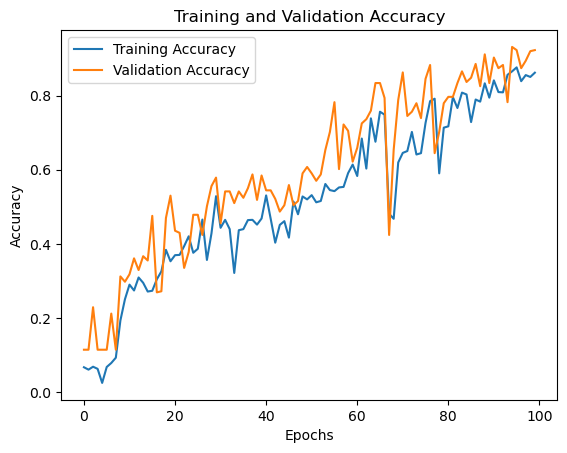

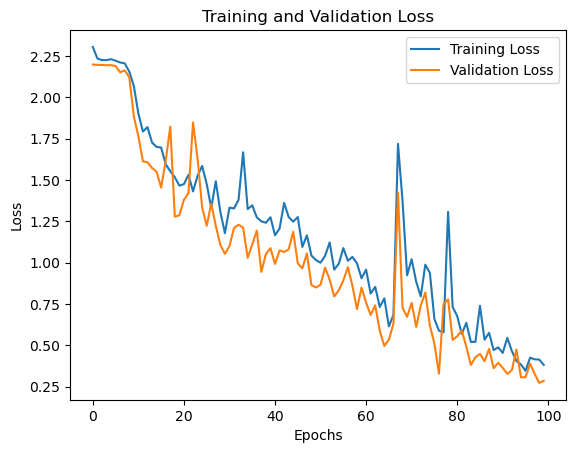

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 442ms/step
[0.9197707736389685, 0.9226361031518625]


In [12]:
model = Sequential()
model.add(Conv2D(filters=32,kernel_size=3, strides=2,padding="same",input_shape=[224, 224, 3],)),PReLU(),
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Conv2D(64,kernel_size = (1,1),strides = (1,1),activation='relu'))
model.add(Conv2D(192,kernel_size = (3,3),strides = (1,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Flatten())

model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(9,activation = 'sigmoid'))
#adam sgd rmsprop,adagrad,adamw

opt =SGD(learning_rate=0.01, momentum=0.9) #stochastic Gradient Descent
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])



# Training the CNN on the Training set and evaluating it on the Test set
r=model.fit(x = training_set, validation_data = test_set, epochs = epoch)





plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
Y_pred = model.predict(test_set)
y_pred = np.argmax(Y_pred, axis=1)
count=0
count=sum(y_pred==test_set.classes)
Acc=count/349
accuracy_list.append(Acc)
print(accuracy_list)

# RMSprop

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.0521 - loss: 29.0326 - val_accuracy: 0.1519 - val_loss: 2.2125
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.0480 - loss: 2.3960 - val_accuracy: 0.2550 - val_loss: 2.1233
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.1924 - loss: 2.5244 - val_accuracy: 0.4126 - val_loss: 1.9484
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.3438 - loss: 1.9512 - val_accuracy: 0.2951 - val_loss: 1.9443
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.1741 - loss: 1.8716 - val_accuracy: 0.3582 - val_loss: 1.5451
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.2301 - loss: 2.0018 - val_accuracy: 0.4011 - val_loss: 1.4626
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.3447 - loss: 1.4878 - val_accuracy: 0.5817 - val_loss: 1.3913
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.3033 - loss: 1.7258 - val_accuracy: 0.5014 - 

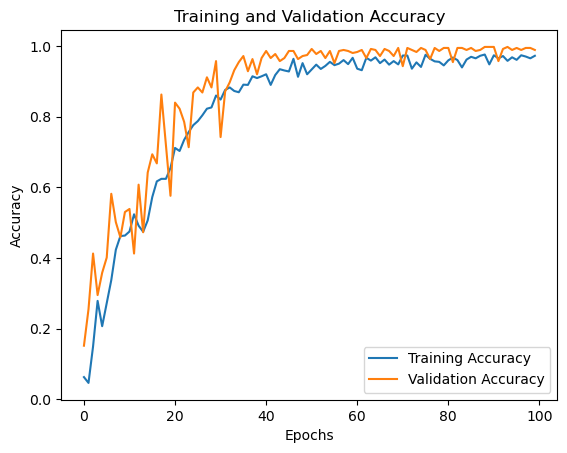

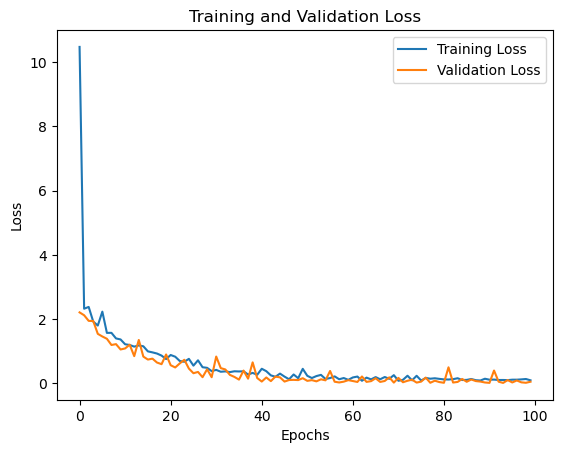

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 447ms/step
[0.9197707736389685, 0.9226361031518625, 0.9799426934097422]


In [13]:
model = Sequential()
model.add(Conv2D(filters=32,kernel_size=3, strides=2,padding="same",input_shape=[224, 224, 3],)),PReLU(),
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Conv2D(64,kernel_size = (1,1),strides = (1,1),activation='relu'))
model.add(Conv2D(192,kernel_size = (3,3),strides = (1,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Flatten())

model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(9,activation = 'sigmoid'))
#adam sgd rmsprop,adagrad,adamw

#opt =SGD(learning_rate=0.01, momentum=0.9) #stochastic Gradient Descent
model.compile(optimizer=RMSprop(), loss='categorical_crossentropy', metrics=['accuracy'])



# Training the CNN on the Training set and evaluating it on the Test set
r=model.fit(x = training_set, validation_data = test_set, epochs = epoch)





plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
Y_pred = model.predict(test_set)
y_pred = np.argmax(Y_pred, axis=1)
count=0
count=sum(y_pred==test_set.classes)
Acc=count/349
accuracy_list.append(Acc)
print(accuracy_list)


# Adagrad

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.1184 - loss: 2.2766 - val_accuracy: 0.1146 - val_loss: 2.1639
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.1085 - loss: 2.1781 - val_accuracy: 0.1834 - val_loss: 2.1408
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.1506 - loss: 2.1653 - val_accuracy: 0.2120 - val_loss: 2.1170
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.1679 - loss: 2.1469 - val_accuracy: 0.2779 - val_loss: 2.0893
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.2333 - loss: 2.1268 - val_accuracy: 0.4097 - val_loss: 2.0553
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.1882 - loss: 2.1192 - val_accuracy: 0.5215 - val_loss: 2.0139
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.2764 - loss: 2.0580 - val_accuracy: 0.5415 - val_loss: 1.9578
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.2476 - loss: 2.0369 - val_accuracy: 0.4241 - v

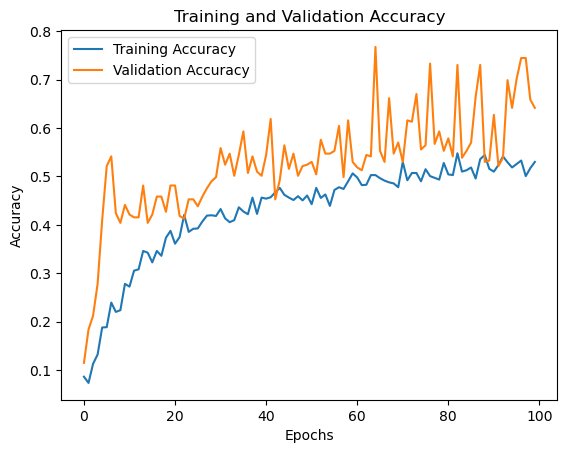

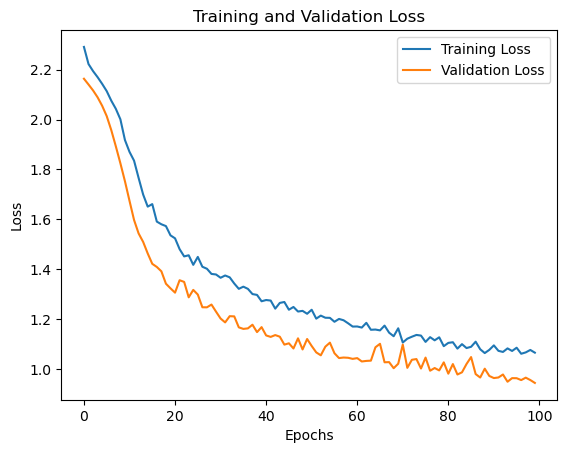

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 439ms/step
[0.9197707736389685, 0.9226361031518625, 0.9799426934097422, 0.6418338108882522]


In [14]:
model = Sequential()
model.add(Conv2D(filters=32,kernel_size=3, strides=2,padding="same",input_shape=[224, 224, 3],)),PReLU(),
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Conv2D(64,kernel_size = (1,1),strides = (1,1),activation='relu'))
model.add(Conv2D(192,kernel_size = (3,3),strides = (1,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Flatten())

model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(9,activation = 'sigmoid'))
#adam sgd rmsprop,adagrad,adamw

#opt =SGD(learning_rate=0.01, momentum=0.9) #stochastic Gradient Descent
model.compile(optimizer=Adagrad(), loss='categorical_crossentropy', metrics=['accuracy'])



# Training the CNN on the Training set and evaluating it on the Test set
r=model.fit(x = training_set, validation_data = test_set, epochs = epoch)





plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
Y_pred = model.predict(test_set)
y_pred = np.argmax(Y_pred, axis=1)
count=0
count=sum(y_pred==test_set.classes)
Acc=count/349
accuracy_list.append(Acc)
print(accuracy_list)

# AdaDelta

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.1112 - loss: 2.2084 - val_accuracy: 0.2350 - val_loss: 2.1906
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.1053 - loss: 2.2104 - val_accuracy: 0.2378 - val_loss: 2.1825
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.1317 - loss: 2.1946 - val_accuracy: 0.2550 - val_loss: 2.1749
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.1232 - loss: 2.1981 - val_accuracy: 0.2550 - val_loss: 2.1679
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.1318 - loss: 2.1877 - val_accuracy: 0.2521 - val_loss: 2.1614
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.1197 - loss: 2.1919 - val_accuracy: 0.2579 - val_loss: 2.1557
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.1526 - loss: 2.1727 - val_accuracy: 0.2636 - val_loss: 2.1501
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.1371 - loss: 2.1855 - val_accuracy: 0.2693 - v

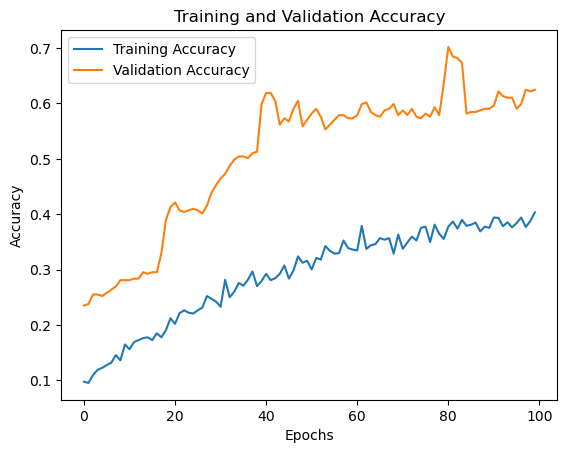

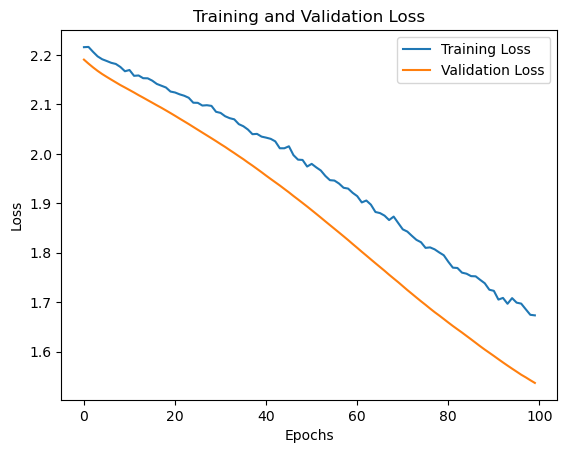

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 444ms/step
[0.9197707736389685, 0.9226361031518625, 0.9799426934097422, 0.6418338108882522, 0.6246418338108882]


In [15]:
model = Sequential()
model.add(Conv2D(filters=32,kernel_size=3, strides=2,padding="same",input_shape=[224, 224, 3],)),PReLU(),
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Conv2D(64,kernel_size = (1,1),strides = (1,1),activation='relu'))
model.add(Conv2D(192,kernel_size = (3,3),strides = (1,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Flatten())

model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(9,activation = 'sigmoid'))
#adam sgd rmsprop,adagrad,adamw

#opt =SGD(learning_rate=0.01, momentum=0.9) #stochastic Gradient Descent
model.compile(optimizer=Adadelta(), loss='categorical_crossentropy', metrics=['accuracy'])



# Training the CNN on the Training set and evaluating it on the Test set
r=model.fit(x = training_set, validation_data = test_set, epochs = epoch)





plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
Y_pred = model.predict(test_set)
y_pred = np.argmax(Y_pred, axis=1)
count=0
count=sum(y_pred==test_set.classes)
Acc=count/349
accuracy_list.append(Acc)
print(accuracy_list)

# Nadam

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.1156 - loss: 5.9492 - val_accuracy: 0.1146 - val_loss: 2.1965
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.0733 - loss: 2.2004 - val_accuracy: 0.0716 - val_loss: 2.1775
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.1313 - loss: 2.1297 - val_accuracy: 0.1146 - val_loss: 2.2206
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.0825 - loss: 2.2380 - val_accuracy: 0.3009 - val_loss: 1.9797
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.2660 - loss: 2.0563 - val_accuracy: 0.3524 - val_loss: 1.6539
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.3037 - loss: 1.6846 - val_accuracy: 0.3811 - val_loss: 1.5444
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.3801 - loss: 1.6987 - val_accuracy: 0.3983 - val_loss: 1.4232
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.3681 - loss: 1.5783 - val_accuracy: 0.4097 - v

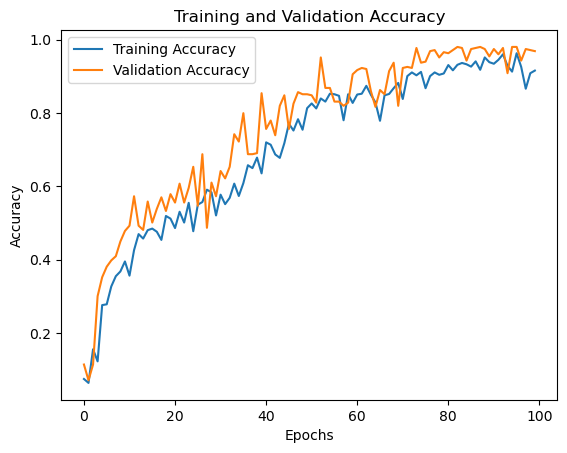

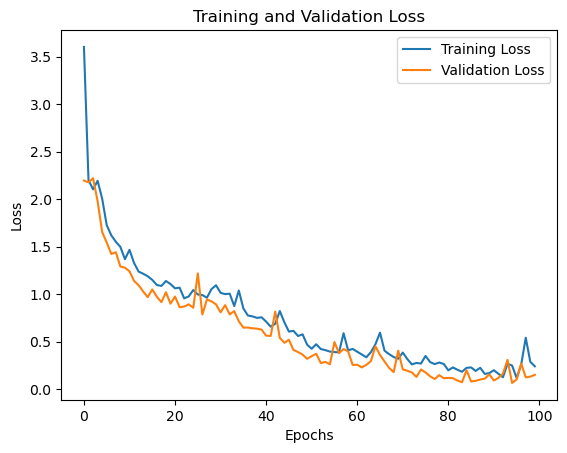

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 446ms/step
[0.9197707736389685, 0.9226361031518625, 0.9799426934097422, 0.6418338108882522, 0.6246418338108882, 0.9684813753581661]


In [16]:
model = Sequential()
model.add(Conv2D(filters=32,kernel_size=3, strides=2,padding="same",input_shape=[224, 224, 3],)),PReLU(),
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Conv2D(64,kernel_size = (1,1),strides = (1,1),activation='relu'))
model.add(Conv2D(192,kernel_size = (3,3),strides = (1,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Flatten())

model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(9,activation = 'sigmoid'))
#adam sgd rmsprop,adagrad,adamw

#opt =SGD(learning_rate=0.01, momentum=0.9) #stochastic Gradient Descent
model.compile(optimizer=Nadam(), loss='categorical_crossentropy', metrics=['accuracy'])



# Training the CNN on the Training set and evaluating it on the Test set
r=model.fit(x = training_set, validation_data = test_set, epochs = epoch)





plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
Y_pred = model.predict(test_set)
y_pred = np.argmax(Y_pred, axis=1)
count=0
count=sum(y_pred==test_set.classes)
Acc=count/349
accuracy_list.append(Acc)
print(accuracy_list)

# FTRL

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.0153 - loss: 2.1980 - val_accuracy: 0.1146 - val_loss: 2.1972
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.0266 - loss: 2.1974 - val_accuracy: 0.1146 - val_loss: 2.1972
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.0583 - loss: 2.1972 - val_accuracy: 0.1146 - val_loss: 2.1972
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.1050 - loss: 2.1970 - val_accuracy: 0.1146 - val_loss: 2.1972
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.1299 - loss: 2.1973 - val_accuracy: 0.1146 - val_loss: 2.1972
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.1137 - loss: 2.1973 - val_accuracy: 0.1146 - val_loss: 2.1972
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.0750 - loss: 2.1972 - val_accuracy: 0.1146 - val_loss: 2.1972
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.0855 - loss: 2.1973 - val_accuracy: 0.1146 - v

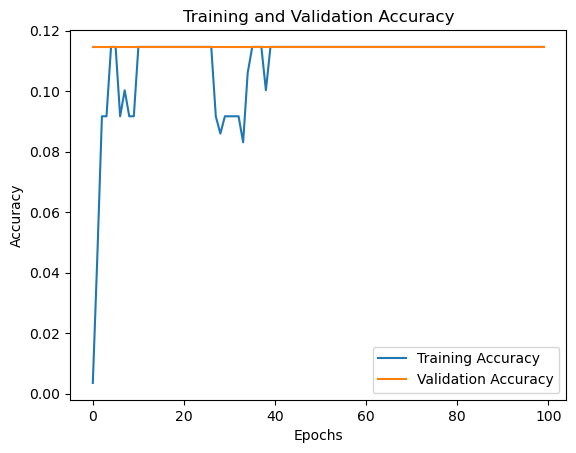

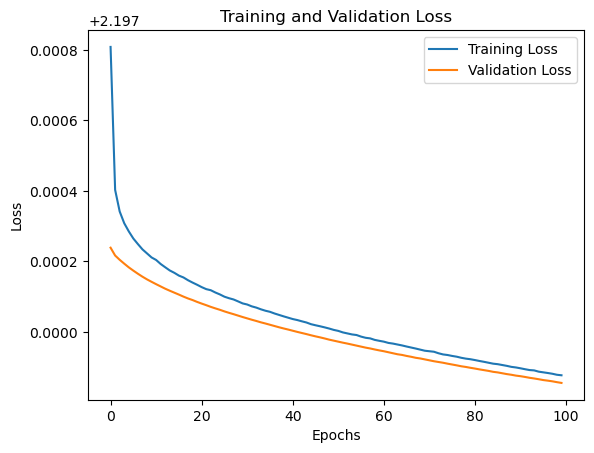

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 446ms/step
[0.9197707736389685, 0.9226361031518625, 0.9799426934097422, 0.6418338108882522, 0.6246418338108882, 0.9684813753581661, 0.11461318051575932]


In [17]:
model = Sequential()
model.add(Conv2D(filters=32,kernel_size=3, strides=2,padding="same",input_shape=[224, 224, 3],)),PReLU(),
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Conv2D(64,kernel_size = (1,1),strides = (1,1),activation='relu'))
model.add(Conv2D(192,kernel_size = (3,3),strides = (1,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Flatten())

model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(9,activation = 'sigmoid'))
#adam sgd rmsprop,adagrad,adamw

#opt =SGD(learning_rate=0.01, momentum=0.9) #stochastic Gradient Descent
model.compile(optimizer='FTRL', loss='categorical_crossentropy', metrics=['accuracy'])



# Training the CNN on the Training set and evaluating it on the Test set
r=model.fit(x = training_set, validation_data = test_set, epochs = epoch)





plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
Y_pred = model.predict(test_set)
y_pred = np.argmax(Y_pred, axis=1)
count=0
count=sum(y_pred==test_set.classes)
Acc=count/349
accuracy_list.append(Acc)
print(accuracy_list)

# AdamW

44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.0747 - loss: 7.4917 - val_accuracy: 0.1146 - val_loss: 2.1974


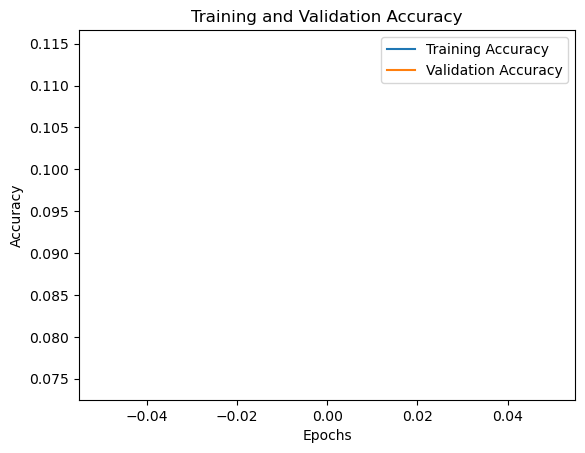

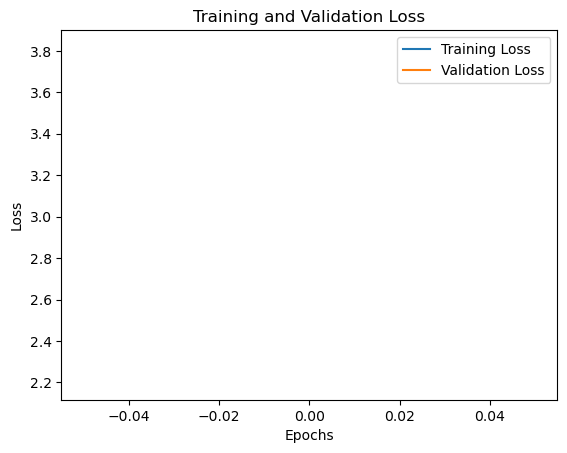

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 462ms/step
[0.9197707736389685, 0.9226361031518625, 0.9799426934097422, 0.6418338108882522, 0.6246418338108882, 0.9684813753581661, 0.11461318051575932, 0.11461318051575932]


In [18]:
model = Sequential()
model.add(Conv2D(filters=32,kernel_size=3, strides=2,padding="same",input_shape=[224, 224, 3],)),PReLU(),
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Conv2D(64,kernel_size = (1,1),strides = (1,1),activation='relu'))
model.add(Conv2D(192,kernel_size = (3,3),strides = (1,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Flatten())

model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(9,activation = 'sigmoid'))
#adam sgd rmsprop,adagrad,adamw

#opt =SGD(learning_rate=0.01, momentum=0.9) #stochastic Gradient Descent
model.compile(optimizer=AdamW(), loss='categorical_crossentropy', metrics=['accuracy'])



# Training the CNN on the Training set and evaluating it on the Test set
r=model.fit(x = training_set, validation_data = test_set, epochs = 1)





plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
Y_pred = model.predict(test_set)
y_pred = np.argmax(Y_pred, axis=1)
count=0
count=sum(y_pred==test_set.classes)
Acc=count/349
accuracy_list.append(Acc)
print(accuracy_list)

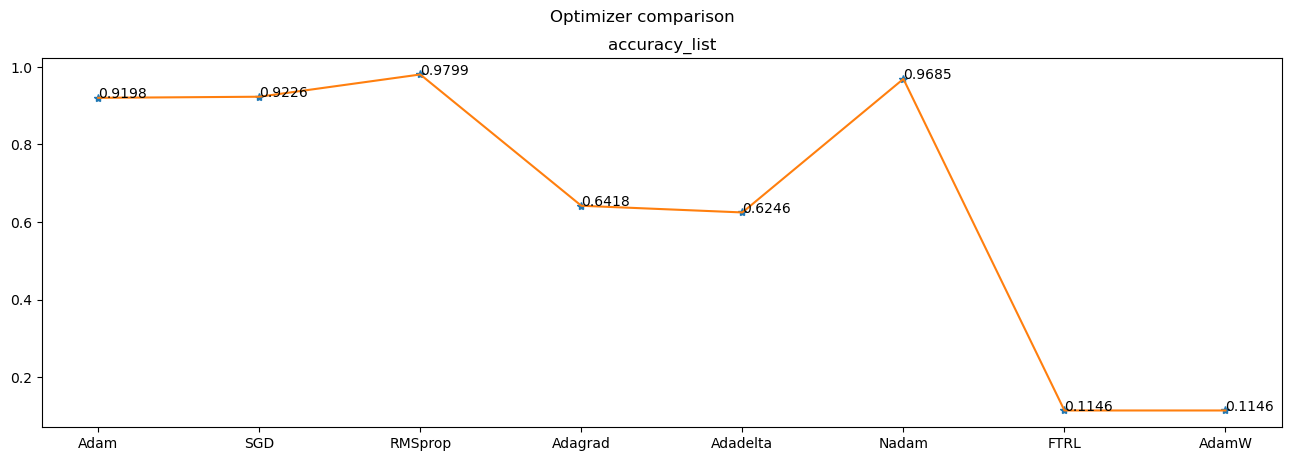

In [1]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots()
fig.set_figwidth(16)
fig.suptitle('Optimizer comparison')
x = [0,1,2,3,4,5,6,7]
accuracy_list=[0.9197707736389685, 0.9226361031518625, 0.9799426934097422, 0.6418338108882522, 0.6246418338108882, 0.9684813753581661, 0.11461318051575932, 0.11461318051575932]
ax.set_xticks(x)
ax.set_xticklabels(['Adam','SGD','RMSprop','Adagrad','Adadelta','Nadam','FTRL','AdamW'])
ax.set_title('accuracy_list')
ax.plot(accuracy_list,'*')
ax.plot(accuracy_list)
for i in range(len(accuracy_list)):
    accuracy_list[i] = round(accuracy_list[i],4)
for i,j in zip(x,accuracy_list):
    ax.annotate(str(j),xy=(i,j))
